# Holistic Data Preparer — Final Project
### Customer Credit Risk Dataset: End-to-End Data Preprocessing & Feature Engineering

## Import Libraries 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Imputation
from sklearn.impute import SimpleImputer, KNNImputer  
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Encoding & Scaling
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, PowerTransformer, OrdinalEncoder
from sklearn.preprocessing import FunctionTransformer, Normalizer

# Others
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from scipy import stats
from scipy.stats.mstats import winsorize

# data sources
import json
import sqlite3
import requests

In [4]:
# ── Plot Style ──
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})
COLORS = sns.color_palette('muted')

In [5]:
import warnings  
warnings.filterwarnings("ignore")

- used to hide warning messages so that the output looks clean.

## **Part B** - Data Acquisition

#### **Task 3** - Import Dataset Multiple Sources 

In [9]:
# CSV
df = pd.read_csv("customer_credit_risk_dataset.csv")
print("csv loaded.")

csv loaded.


In [11]:
# JSON 
json_data = {
    "customers": [
        {"customer_id": 1, "loyalty_score": 8.5, "vip": True},
        {"customer_id": 2, "loyalty_score": 6.2, "vip": False},
        {"customer_id": 3, "loyalty_score": 7.9, "vip": True},
    ]
}
df_json = pd.DataFrame(json_data["customers"])
print(f"\nJSON shape: {df_json.shape}")
df_json


JSON shape: (3, 3)


,customer_id,loyalty_score,vip
0,1,8.5,True
1,2,6.2,False
2,3,7.9,True


In [13]:
# SQL
conn = sqlite3.connect(":memory:")
conn.execute("""CREATE TABLE repayment (
                    customer_id INTEGER, last_payment_date TEXT,
                    total_paid REAL)""")
conn.executemany("INSERT INTO repayment VALUES (?,?,?)",
                 [(1, "2024-01-15", 5000.0),
                  (2, "2023-11-20", 3200.0),
                  (3, "2024-03-05", 7800.0)])
conn.commit()
df_sql = pd.read_sql("SELECT * FROM repayment", conn)
print(f"\nSQL shape: {df_sql.shape}")
df_sql


SQL shape: (3, 3)


,customer_id,last_payment_date,total_paid
0,1,2024-01-15,5000.0
1,2,2023-11-20,3200.0
2,3,2024-03-05,7800.0


In [15]:
# API 
def fetch_dummy_api():
    return {"inflation_rate": 5.2, "gdp_growth": 2.8, "unemployment": 4.1}
 
api_data = fetch_dummy_api()
df_api = pd.DataFrame([api_data])
print(f"\nAPI shape: {df_api.shape}")
df_api


API shape: (1, 3)


,inflation_rate,gdp_growth,unemployment
0,5.2,2.8,4.1


## **Part C** - Data Understanding & Cleaning 

#### **Task 4** - Explore Dataset

In [17]:
df.info()     # basic information about the dataset
df.describe()  # statistical summary
df.isnull().sum()  # total missing (null) values in each column.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        650 non-null    object 
 1   age                605 non-null    float64
 2   gender             620 non-null    object 
 3   region             650 non-null    object 
 4   education_level    650 non-null    object 
 5   employment_type    610 non-null    object 
 6   annual_income      600 non-null    float64
 7   loan_amount        650 non-null    float64
 8   loan_purpose       650 non-null    object 
 9   credit_score       615 non-null    float64
 10  repayment_history  650 non-null    int64  
 11  transaction_count  650 non-null    int64  
 12  spending_ratio     650 non-null    float64
 13  join_date          650 non-null    object 
 14  default_flag       650 non-null    int64  
dtypes: float64(5), int64(3), object(7)
memory usage: 76.3+ KB


customer_id           0
age                  45
gender               30
region                0
education_level       0
employment_type      40
annual_income        50
loan_amount           0
loan_purpose          0
credit_score         35
repayment_history     0
transaction_count     0
spending_ratio        0
join_date             0
default_flag          0
dtype: int64

#### **Task 5** - Perform Pandas Profiling 

In [17]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, explorative=True)
profile.to_file("report.html")
print("Created Report file.")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 21.01it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Created Report file.


### **Visual** -  Missing Values Heatmap & Bar Chart

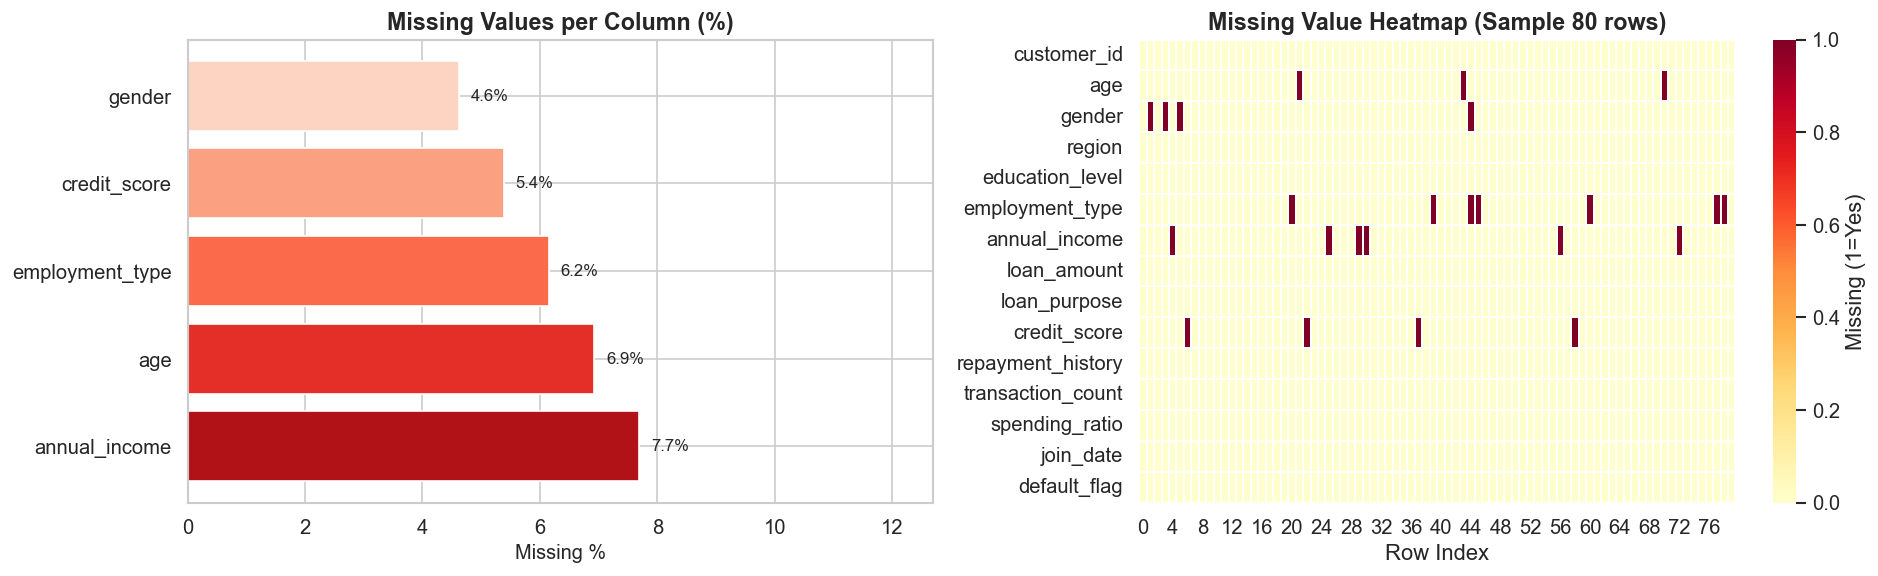

Missing Values: age, gender, employment_type, annual_income, credit_score have injected nulls.


In [19]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Bar Chart ──
bars = axes[0].barh(missing_pct.index, missing_pct.values,
                    color=sns.color_palette('Reds_r', len(missing_pct)))
axes[0].set_xlabel('Missing %', fontsize=12)
axes[0].set_title('Missing Values per Column (%)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, missing_pct.values):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10)
axes[0].set_xlim(0, missing_pct.max() + 5)

# ── Heatmap ──
missing_matrix = df.isnull().astype(int)
sample_rows = missing_matrix.sample(min(80, len(df)), random_state=42).reset_index(drop=True)
sns.heatmap(sample_rows.T, ax=axes[1], cmap='YlOrRd',
            cbar_kws={'label': 'Missing (1=Yes)'}, linewidths=0.1)
axes[1].set_title('Missing Value Heatmap (Sample 80 rows)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Row Index')

plt.tight_layout()
plt.savefig('viz_missing_values.png', bbox_inches='tight')
plt.show()
print('Missing Values: age, gender, employment_type, annual_income, credit_score have injected nulls.')

#### **Task 6**
- Simple Imputer
- Most Frequent Category Imputation
- Missing Indicator + Random Sample Imputation
- KNN Imputer
- MICE Algorithm

In [21]:
df_clean = df.copy()

# age — mean
df_clean['age'] = SimpleImputer(strategy='mean').fit_transform(df_clean[['age']]).ravel()

# gender, employment_type — most_frequent
df_clean['gender'] = SimpleImputer(strategy='most_frequent').fit_transform(df_clean[['gender']]).ravel()
df_clean['employment_type'] = SimpleImputer(strategy='most_frequent').fit_transform(df_clean[['employment_type']]).ravel()

# annual_income — missing indicator + random sample
df_clean['annual_income_missing'] = df_clean['annual_income'].isnull().astype(int)
not_null_income = df_clean['annual_income'].dropna()
n_miss = df_clean['annual_income'].isnull().sum()
df_clean.loc[df_clean['annual_income'].isnull(), 'annual_income'] = not_null_income.sample(n=n_miss, random_state=42).values

# credit_score, loan_amount — KNN
knn_cols = ['annual_income','loan_amount','credit_score']
df_clean[knn_cols] = KNNImputer(n_neighbors=5).fit_transform(df_clean[knn_cols])

# All numeric — MICE
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
df_clean[num_cols] = IterativeImputer(max_iter=10, random_state=42).fit_transform(df_clean[num_cols])

print('Missing values handled!')
print('Remaining nulls:\n', df_clean.isnull().sum()[df_clean.isnull().sum()>0])

Missing values handled!
Remaining nulls:
 Series([], dtype: int64)


## **Part D** - Outliers Handling

#### **Task 7**
- Z-score
- IQR
- Percentile
- Winsorization

In [23]:
# Z-score
outlier_cols = ['annual_income', 'loan_amount', 'credit_score']
print('Z-Score (|z|>3):')
for col in outlier_cols:
    n = (np.abs(stats.zscore(df_clean[col])) > 3).sum()
    print(f'   {col}: {n} outliers')

# IQR Method
print('\nIQR Method:')
for col in outlier_cols:
    Q1,Q3 = df_clean[col].quantile([.25,.75])
    IQR = Q3-Q1
    n = ((df_clean[col]<Q1-1.5*IQR)|(df_clean[col]>Q3+1.5*IQR)).sum()
    print(f'   {col}: {n} outliers | Bounds [{Q1-1.5*IQR:.0f}, {Q3+1.5*IQR:.0f}]')

Z-Score (|z|>3):
   annual_income: 8 outliers
   loan_amount: 9 outliers
   credit_score: 10 outliers

IQR Method:
   annual_income: 37 outliers | Bounds [-84686, 313139]
   loan_amount: 45 outliers | Bounds [-133356, 504761]
   credit_score: 13 outliers | Bounds [394, 816]


### **Visual** -  Winsorization Before vs After

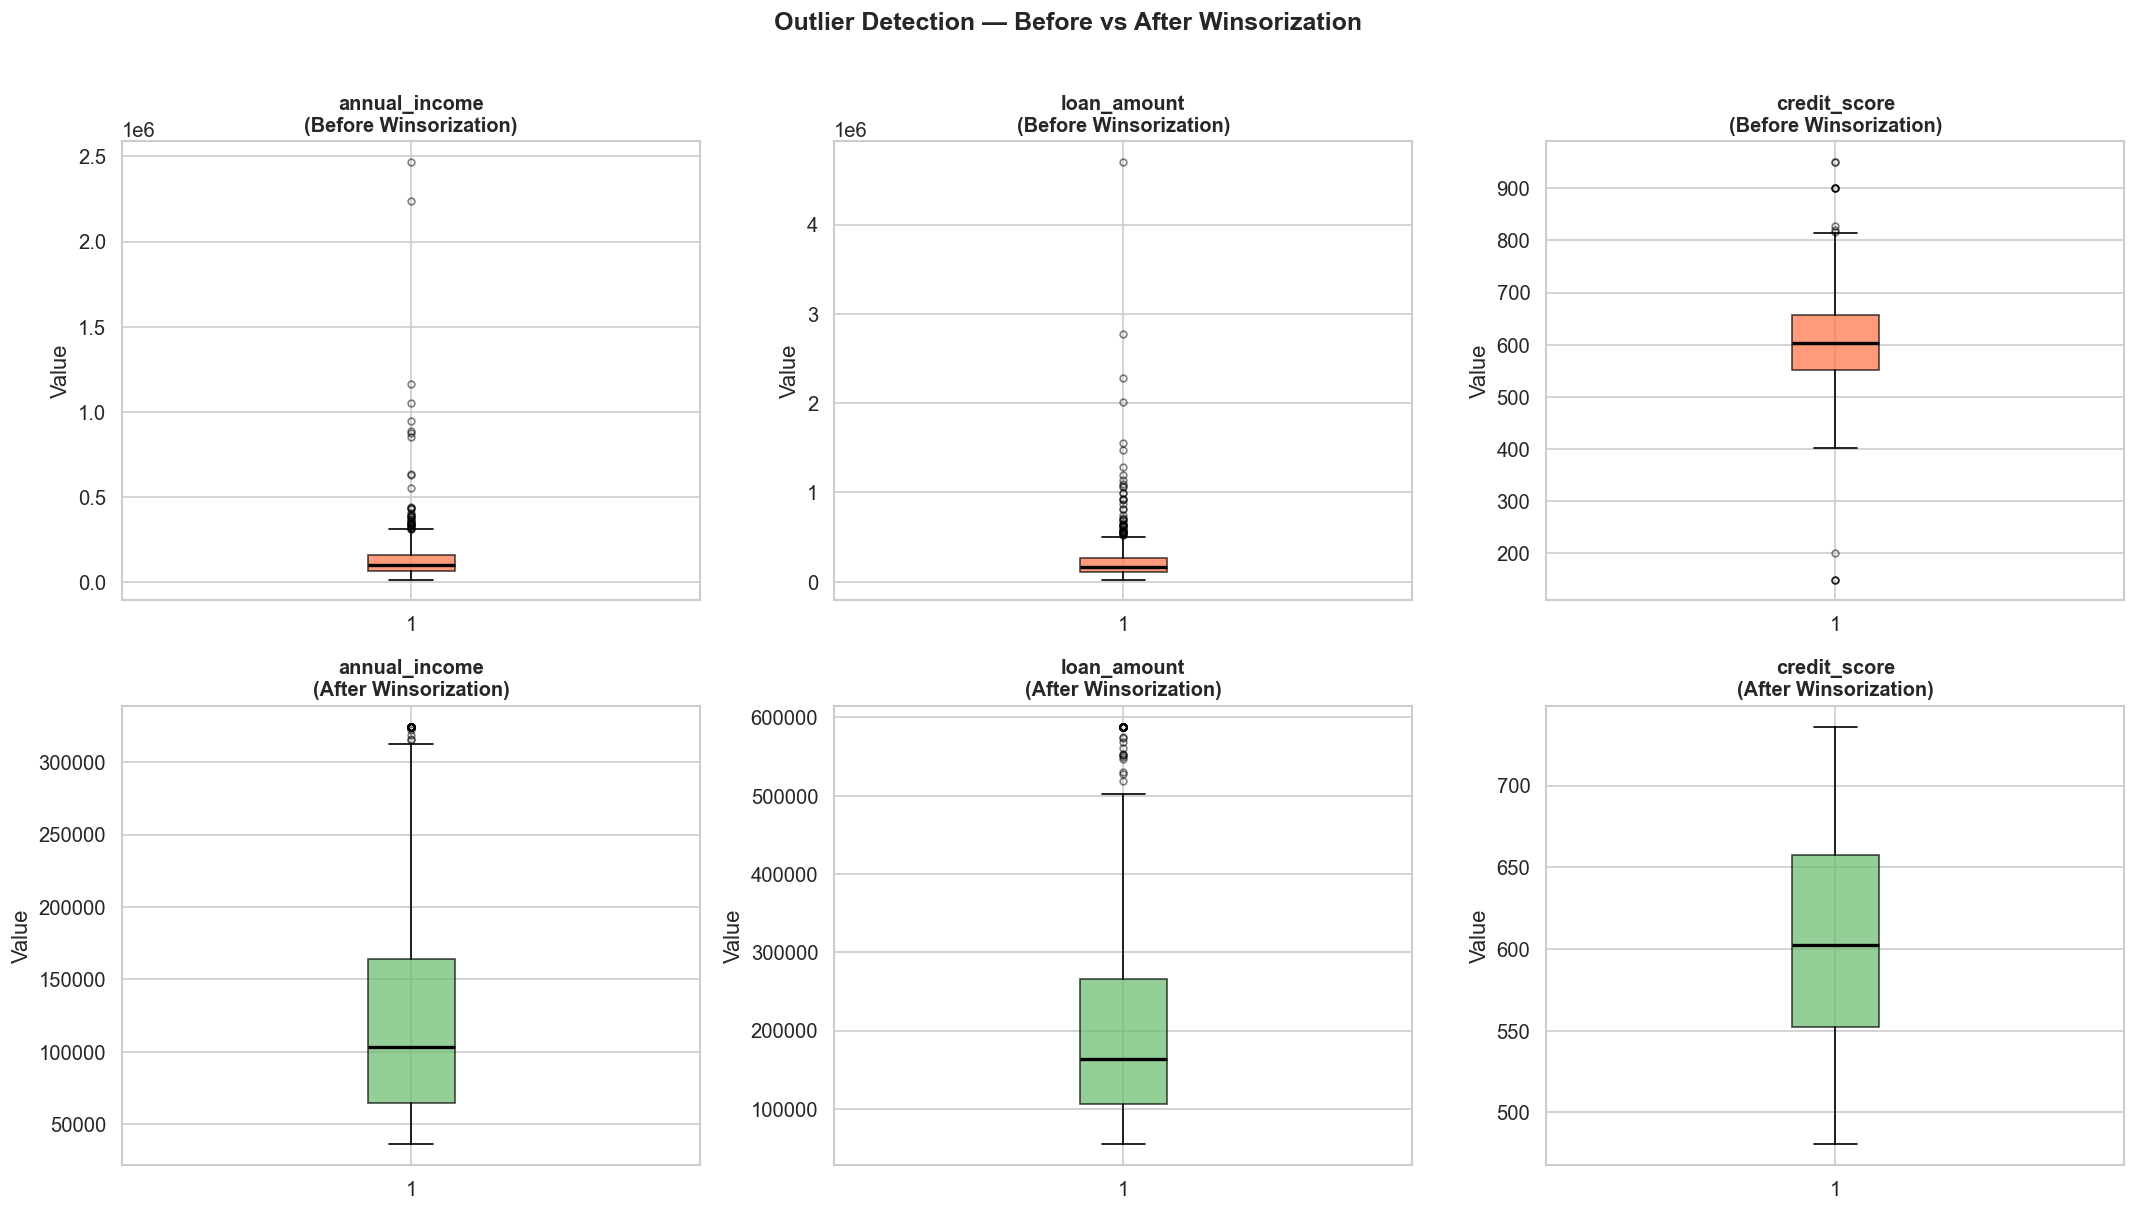

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
outlier_cols = ['annual_income', 'loan_amount', 'credit_score']

df_before = df_clean.copy()

# Winsorize 
df_after = df_clean.copy()
for col in outlier_cols:
    lo, hi = df_after[col].quantile([0.05, 0.95])
    df_after[col] = df_after[col].clip(lo, hi)

for i, col in enumerate(outlier_cols):
    # Before
    bp1 = axes[0][i].boxplot(df_before[col], vert=True, patch_artist=True,
                              boxprops=dict(facecolor='#FF7043', alpha=0.7),
                              medianprops=dict(color='black', linewidth=2),
                              flierprops=dict(marker='o', color='red', alpha=0.5, markersize=4))
    axes[0][i].set_title(f'{col}\n(Before Winsorization)', fontsize=12, fontweight='bold')
    axes[0][i].set_ylabel('Value')

    # After
    bp2 = axes[1][i].boxplot(df_after[col], vert=True, patch_artist=True,
                              boxprops=dict(facecolor='#66BB6A', alpha=0.7),
                              medianprops=dict(color='black', linewidth=2),
                              flierprops=dict(marker='o', color='green', alpha=0.5, markersize=4))
    axes[1][i].set_title(f'{col}\n(After Winsorization)', fontsize=12, fontweight='bold')
    axes[1][i].set_ylabel('Value')

plt.suptitle('Outlier Detection — Before vs After Winsorization', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_outliers_boxplot.png', bbox_inches='tight')
plt.show()

## **Part E** - Feature Engineering

#### **Task 8** Handle Varible Types

In [27]:
df_clean['join_date'] = pd.to_datetime(df_clean['join_date'])
df_clean['join_year']    = df_clean['join_date'].dt.year
df_clean['join_month']   = df_clean['join_date'].dt.month
df_clean['join_day']     = df_clean['join_date'].dt.day
df_clean['join_weekday'] = df_clean['join_date'].dt.dayofweek
df_clean['tenure_days']  = (pd.Timestamp('today') - df_clean['join_date']).dt.days
print('Date features extracted')
df_clean[['join_date','join_year','join_month','tenure_days']].head()

Date features extracted


,join_date,join_year,join_month,tenure_days
0,2020-06-22,2020,6,2103
1,2017-06-17,2017,6,3204
2,2018-01-22,2018,1,2985
3,2019-11-21,2019,11,2317
4,2020-06-12,2020,6,2113


#### **Task 9 & 10** - Encoding Categorical & Numerical
- Ordinal
- Label
- One-hot
- Binning
- Binarization
- Ouantile 
- K-means

In [29]:
# Ordinal
edu_order = [['Primary','Secondary','Graduate','Post-Graduate']]
df_clean['education_encoded'] = OrdinalEncoder(categories=edu_order).fit_transform(df_clean[['education_level']]).astype(int)

# Label
le = LabelEncoder()
df_clean['gender_encoded'] = le.fit_transform(df_clean['gender'])

# One-Hot
df_clean = pd.get_dummies(df_clean, columns=['region','loan_purpose'], prefix=['region','purpose'])

# Binning
df_clean['income_bin']     = pd.cut(df_clean['annual_income'],
    bins=[0,200000,400000,600000,800000,np.inf],
    labels=['Very Low','Low','Medium','High','Very High'])
df_clean['repayment_bin']  = pd.cut(df_clean['repayment_history'],
    bins=[-1,2,5,8,np.inf], labels=['Excellent','Good','Fair','Poor'])

# Binarization
from sklearn.preprocessing import Binarizer
df_clean['good_credit'] = Binarizer(threshold=700).fit_transform(df_clean[['credit_score']]).astype(int)

# Quantile Binning
df_clean['trans_quantile'] = pd.qcut(df_clean['transaction_count'], q=4,
    labels=['Q1','Q2','Q3','Q4'], duplicates='drop')

# K-Means Binning
from sklearn.cluster import KMeans
df_clean['trans_kmeans'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(df_clean[['transaction_count']])

print('All encodings applied!')
print(f'Dataset shape: {df_clean.shape}')

All encodings applied!
Dataset shape: (650, 35)


### **Visual** - Encoding Results Chart

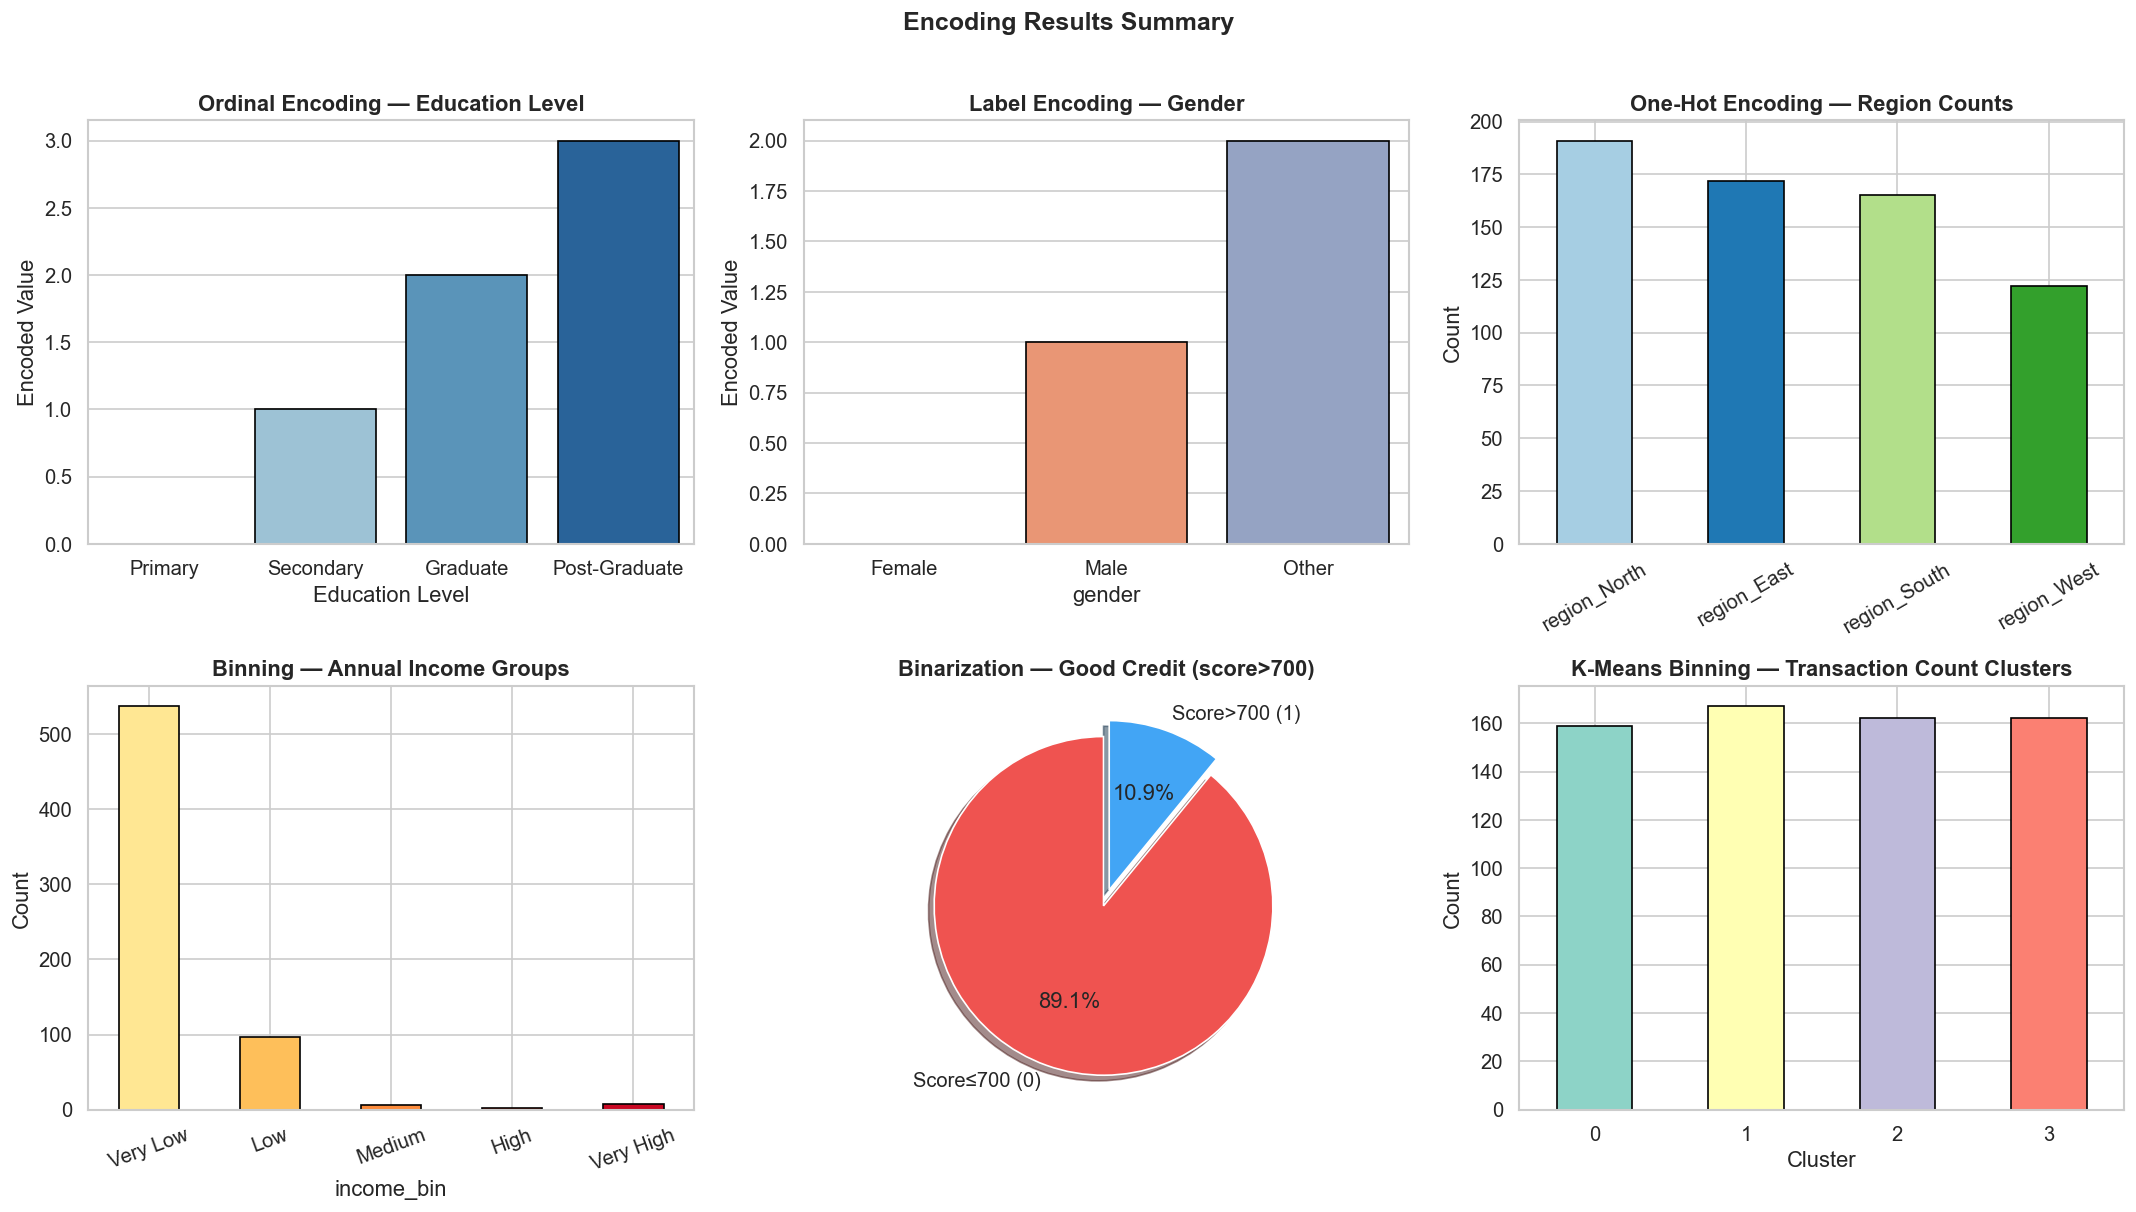

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Ordinal Encoding — education_level
edu_map = df_clean[['education_level','education_encoded']].drop_duplicates().sort_values('education_encoded')
sns.barplot(data=edu_map, x='education_level', y='education_encoded', ax=axes[0][0],
            palette='Blues', edgecolor='black')
axes[0][0].set_title('Ordinal Encoding — Education Level', fontweight='bold')
axes[0][0].set_xlabel('Education Level')
axes[0][0].set_ylabel('Encoded Value')

# 2. Label Encoding — gender
gender_map = df_clean[['gender','gender_encoded']].drop_duplicates().sort_values('gender_encoded')
sns.barplot(data=gender_map, x='gender', y='gender_encoded', ax=axes[0][1],
            palette='Set2', edgecolor='black')
axes[0][1].set_title('Label Encoding — Gender', fontweight='bold')
axes[0][1].set_ylabel('Encoded Value')

# 3. OHE — region distribution
region_cols = [c for c in df_clean.columns if c.startswith('region_')]
region_counts = df_clean[region_cols].sum().sort_values(ascending=False)
region_counts.plot(kind='bar', ax=axes[0][2], color=sns.color_palette('Paired',len(region_counts)), edgecolor='black')
axes[0][2].set_title('One-Hot Encoding — Region Counts', fontweight='bold')
axes[0][2].set_ylabel('Count')
axes[0][2].tick_params(axis='x', rotation=30)

# 4. Income Bin distribution
income_bin_counts = df_clean['income_bin'].value_counts().sort_index()
income_bin_counts.plot(kind='bar', ax=axes[1][0],
    color=sns.color_palette('YlOrRd', len(income_bin_counts)), edgecolor='black')
axes[1][0].set_title('Binning — Annual Income Groups', fontweight='bold')
axes[1][0].set_ylabel('Count')
axes[1][0].tick_params(axis='x', rotation=20)

# 5. Binarization — good_credit
gc_counts = df_clean['good_credit'].value_counts()
axes[1][1].pie(gc_counts, labels=['Score≤700 (0)','Score>700 (1)'],
               autopct='%1.1f%%', colors=['#EF5350','#42A5F5'],
               startangle=90, explode=(0.05,0.05), shadow=True)
axes[1][1].set_title('Binarization — Good Credit (score>700)', fontweight='bold')

# 6. K-Means Binning — transactions
km_counts = df_clean['trans_kmeans'].value_counts().sort_index()
km_counts.plot(kind='bar', ax=axes[1][2],
    color=sns.color_palette('Set3', len(km_counts)), edgecolor='black')
axes[1][2].set_title('K-Means Binning — Transaction Count Clusters', fontweight='bold')
axes[1][2].set_ylabel('Count')
axes[1][2].set_xlabel('Cluster')
axes[1][2].tick_params(axis='x', rotation=0)

plt.suptitle('Encoding Results Summary', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_encoding_results.png', bbox_inches='tight')
plt.show()

## **Part F** - Feature Scaling

#### **Task 11** - Multiple Scaling Method
- Standardization
- Min-Max Scaling
- Max-Abs Scaling
- Robust Scaling

In [33]:
scale_cols = ['annual_income','loan_amount','credit_score','spending_ratio','age']
df_scale   = df_clean[scale_cols].copy()

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler'  : MinMaxScaler(),
    'MaxAbsScaler'  : MaxAbsScaler(),
    'RobustScaler'  : RobustScaler(),
}

scaled_dfs = {}
for name, scaler in scalers.items():
    scaled_dfs[name] = pd.DataFrame(scaler.fit_transform(df_scale), columns=scale_cols)

# Apply StandardScaler to main df
df_clean[['annual_income_scaled','loan_amount_scaled']] = StandardScaler().fit_transform(
    df_clean[['annual_income','loan_amount']])

print('All scaling applied!')

All scaling applied!


## **Part G** - Feature Construction & Transformation 

#### **Task 12** - Apply Transformation 
- log
- Reciprocal
- Square root
- Box-Cox
- Yeo-Johnson

In [35]:
# ── New Features ──
df_clean['debt_to_income']         = df_clean['loan_amount'] / (df_clean['annual_income'] + 1e-6)
df_clean['avg_monthly_trans']      = df_clean['transaction_count'] / 6.0
df_clean['spending_income_ratio']  = df_clean['spending_ratio'] * df_clean['annual_income'] / 100
df_clean['high_credit_risk']       = (df_clean['credit_score'] < 600).astype(int)
df_clean['loan_burden']            = df_clean['loan_amount'] * df_clean['repayment_history']

# ── Transformations ──
sr = df_clean['spending_ratio'].clip(lower=1e-6)
df_clean['spending_log']  = np.log1p(sr)
df_clean['spending_sqrt'] = np.sqrt(sr)

# Box-Cox on loan_amount
df_clean['loan_boxcox'] = PowerTransformer(method='box-cox').fit_transform(
    df_clean[['loan_amount']].clip(lower=0.01))

# Yeo-Johnson on annual_income
df_clean['income_yj'] = PowerTransformer(method='yeo-johnson').fit_transform(df_clean[['annual_income']])

print('Feature construction complete!')
print(f'   debt_to_income     — mean: {df_clean["debt_to_income"].mean():.3f}')
print(f'   loan_boxcox skew   — {df_clean["loan_boxcox"].skew():.4f} (original: {df_clean["loan_amount"].skew():.4f})')
print(f'   income_yj   skew   — {df_clean["income_yj"].skew():.4f}')

Feature construction complete!
   debt_to_income     — mean: 2.731
   loan_boxcox skew   — -0.0179 (original: 7.7806)
   income_yj   skew   — -0.0163


### **Visual** - Transformation Effects

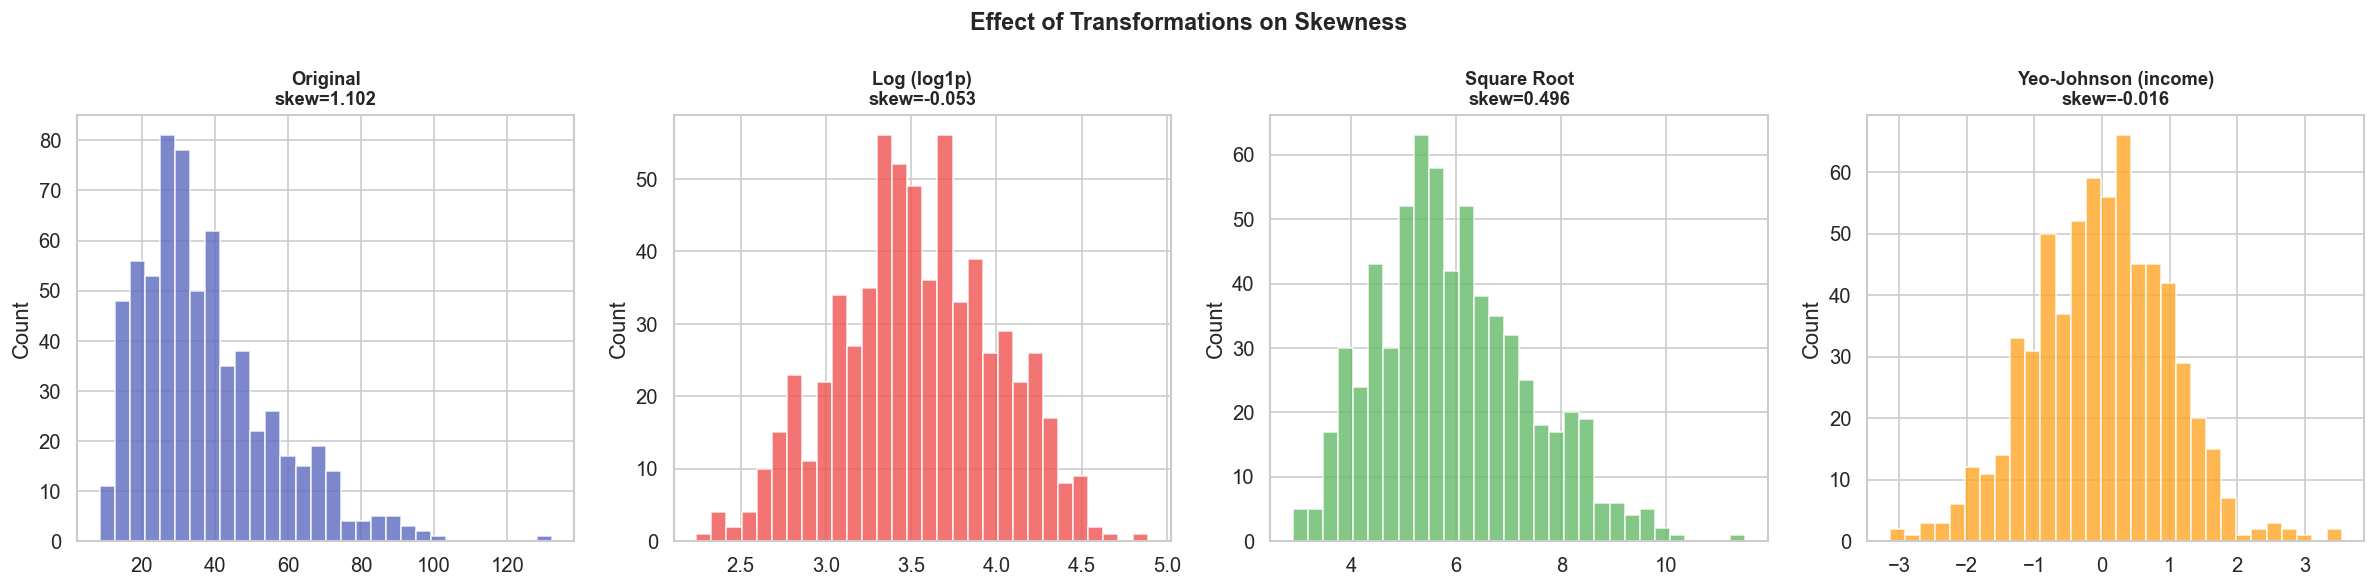

In [37]:
# Visual: Transformation Effect on spending_ratio
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
trans_data = [
    (df_clean['spending_ratio'], 'Original', '#5C6BC0'),
    (df_clean['spending_log'],   'Log (log1p)', '#EF5350'),
    (df_clean['spending_sqrt'],  'Square Root', '#66BB6A'),
    (df_clean['income_yj'],      'Yeo-Johnson (income)', '#FFA726'),
]
for i,(data,title,color) in enumerate(trans_data):
    axes[i].hist(data, bins=30, color=color, alpha=0.8, edgecolor='white')
    axes[i].set_title(f'{title}\nskew={data.skew():.3f}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')

plt.suptitle('Effect of Transformations on Skewness', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_transformations.png', bbox_inches='tight')
plt.show()

## **Part H** - Final Deliverable 

In [39]:
drop_cols = ['customer_id','join_date','education_level','gender',
             'income_bin','repayment_bin','trans_quantile']
df_final = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])

# Convert bool → int
for col in df_final.select_dtypes(include='bool').columns:
    df_final[col] = df_final[col].astype(int)

# Convert remaining object → label encoded
from sklearn.preprocessing import LabelEncoder
for col in df_final.select_dtypes(include='object').columns:
    df_final[col] = LabelEncoder().fit_transform(df_final[col].astype(str))

df_final.to_csv('customer_credit_risk_FINAL.csv', index=False)
print(f'Final Dataset Shape: {df_final.shape}')
print(f'   No nulls: {df_final.isnull().sum().sum()}')
print(f'   Target distribution: {df_final["default_flag"].value_counts().to_dict()}')
df_final.head()

Final Dataset Shape: (650, 39)
   No nulls: 0
   Target distribution: {0.0: 517, 1.0: 133}


,age,employment_type,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio,default_flag,annual_income_missing,...,loan_amount_scaled,debt_to_income,avg_monthly_trans,spending_income_ratio,high_credit_risk,loan_burden,spending_log,spending_sqrt,loan_boxcox,income_yj
0,59.0,0,43347.13,99011.80,693.4,2.0,58.0,20.20,1.0,0.0,...,-0.457003,2.284160,9.666667,8.756120e+03,0,198023.60,3.054001,4.494441,-0.745485,-1.361955
1,49.0,1,64494.51,200534.22,600.2,5.0,50.0,101.54,1.0,0.0,...,-0.114773,3.109322,8.333333,6.548773e+04,0,1002671.10,4.630253,10.076706,0.288634,-0.697886
2,35.0,0,83022.82,162229.10,466.6,2.0,38.0,42.02,0.0,0.0,...,-0.243899,1.954030,6.333333,3.488619e+04,1,324458.20,3.761665,6.482284,-0.006735,-0.300967
3,63.0,0,61682.03,210989.79,616.7,0.0,55.0,30.67,0.0,0.0,...,-0.079528,3.420604,9.166667,1.891788e+04,0,0.00,3.455370,5.538050,0.357606,-0.769950
4,28.0,2,2236457.03,1283259.67,638.0,2.0,28.0,67.20,0.0,0.0,...,3.535068,0.573791,4.666667,1.502899e+06,0,2566519.34,4.222445,8.197561,2.402440,3.463806


### **Visual** - Final Summary Dashoard

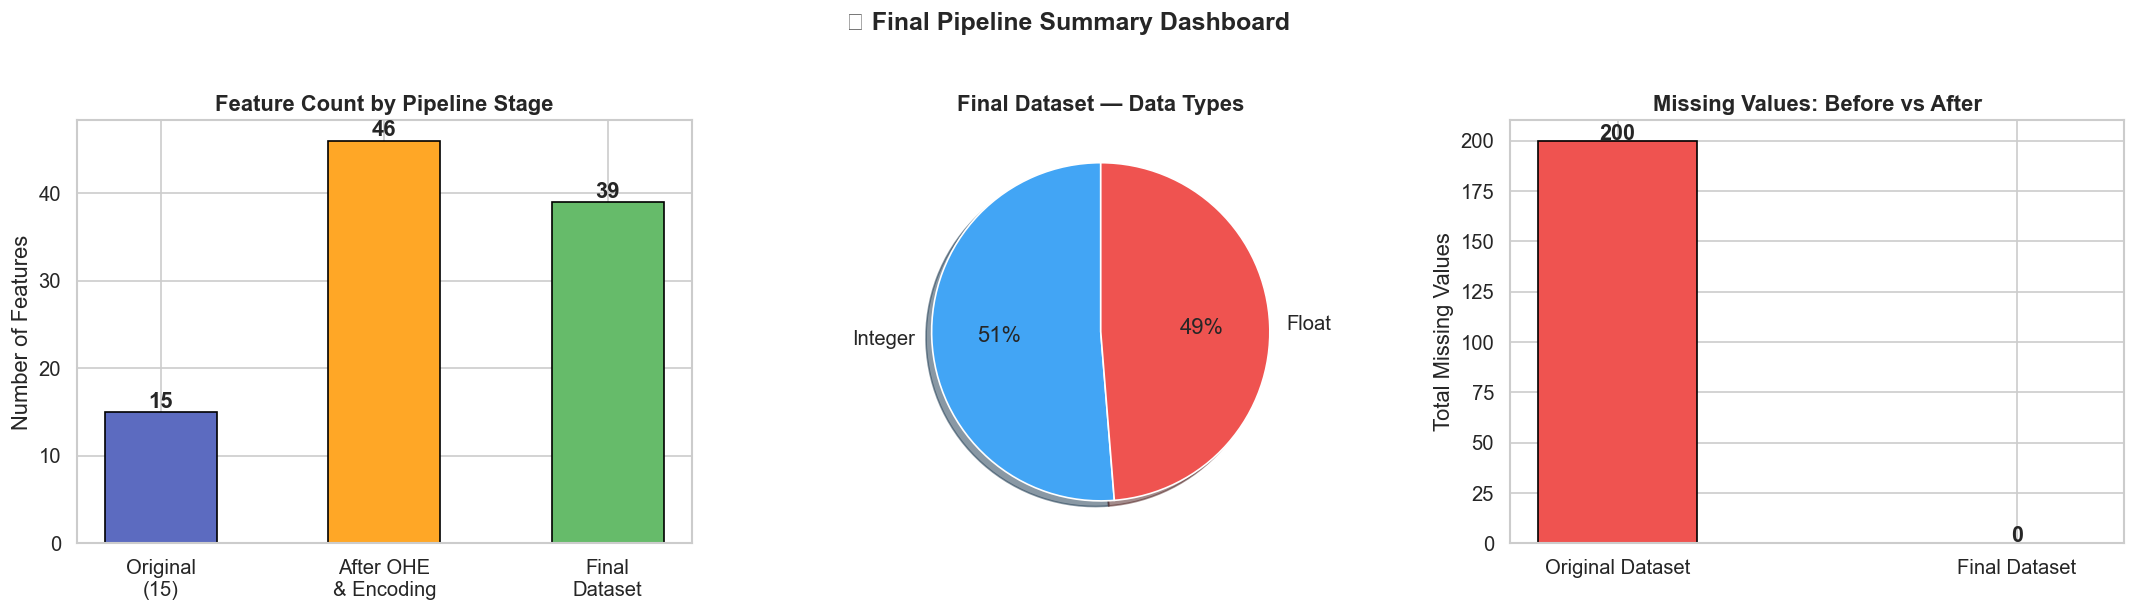

In [41]:
# Final Summary Dashboard
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Feature count comparison
stages = ['Original\n(15)', 'After OHE\n& Encoding', 'Final\nDataset']
counts = [15, df_clean.shape[1], df_final.shape[1]]
bars = axes[0].bar(stages, counts, color=['#5C6BC0','#FFA726','#66BB6A'], edgecolor='black', width=0.5)
axes[0].set_title('Feature Count by Pipeline Stage', fontweight='bold')
axes[0].set_ylabel('Number of Features')
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, str(val), ha='center', fontweight='bold')

# 2. Data types in final dataset
dtype_counts = df_final.dtypes.astype(str).map(lambda x: 'Float' if 'float' in x else 'Integer' if 'int' in x else 'Other').value_counts()
axes[1].pie(dtype_counts, labels=dtype_counts.index, autopct='%1.0f%%',
            colors=['#42A5F5','#EF5350','#66BB6A'], startangle=90, shadow=True)
axes[1].set_title('Final Dataset — Data Types', fontweight='bold')

# 3. Missing values: original vs final
orig_miss  = df.isnull().sum().sum()
final_miss = df_final.isnull().sum().sum()
axes[2].bar(['Original Dataset','Final Dataset'], [orig_miss, final_miss],
            color=['#EF5350','#66BB6A'], edgecolor='black', width=0.4)
axes[2].set_title('Missing Values: Before vs After', fontweight='bold')
axes[2].set_ylabel('Total Missing Values')
for i,(v) in enumerate([orig_miss, final_miss]):
    axes[2].text(i, v+0.5, str(v), ha='center', fontweight='bold', fontsize=13)

plt.suptitle('🏁 Final Pipeline Summary Dashboard', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_final_summary.png', bbox_inches='tight')
plt.show()

---
## Project Complete!
All visualizations saved as PNG files. Final dataset: `customer_credit_risk_FINAL.csv`

| Visual | File |
|--------|------|
| Missing Values | `viz_missing_values.png` |
| Outlier Boxplots | `viz_outliers_boxplot.png` |
| Encoding Results | `viz_encoding_results.png` |
| Final Dashboard | `viz_final_summary.png` |